# Customer Churn Analysis & Prediction


This notebook explores a customer churn dataset visualizes what separates churned vs retained customers and builds two models to predict churn.

**What I will do:**
1. Load and inspect the data
2. Explore it visually (EDA)
3. Prepare the data for machine learning
4. Train two models (Logistic Regression + Random Forest)
5. Evaluate which one performs better and why
6. Identify which factors matter most
7. Export a churn-risk-scored customer list for the Power BI dashboard

# Installation of libraries:

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, roc_auc_score, roc_curve)

## 1. Load the data
I started by loading the CSV into a pandas DataFrame.

In [61]:
df = pd.read_csv("/Users/mahmudulhasan/Desktop/Churn_project/customer_churn_dataset-testing-master.csv")
print("Loaded", len(df), "customers")
df.head()

Loaded 64374 customers


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [63]:
# Churn is our target: 1 = customer left, 0 = customer stayed
churn_rate = df["Churn"].mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")
df["Churn"].value_counts()

Overall churn rate: 47.4%


Churn
0    33881
1    30493
Name: count, dtype: int64

## 2. Explore the data (EDA)
Before modeling anything, let's look at which factors seem connected to churn. This is the same analysis I did in SQL.Now I will present  with visualization.

### Churn rate by contract length

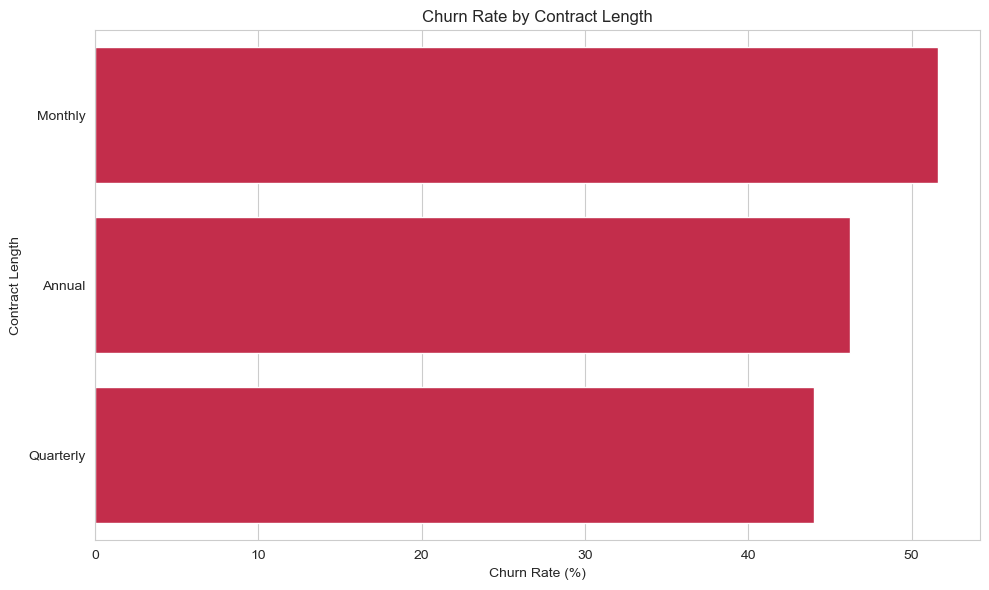

In [118]:
churn_by_contract = df.groupby("Contract Length")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_contract.values, y=churn_by_contract.index,color="crimson", orient="h")
plt.title("Churn Rate by Contract Length")
plt.xlabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("chart_churn_by_contract.png")
plt.show()

### Churn rate by subscription type

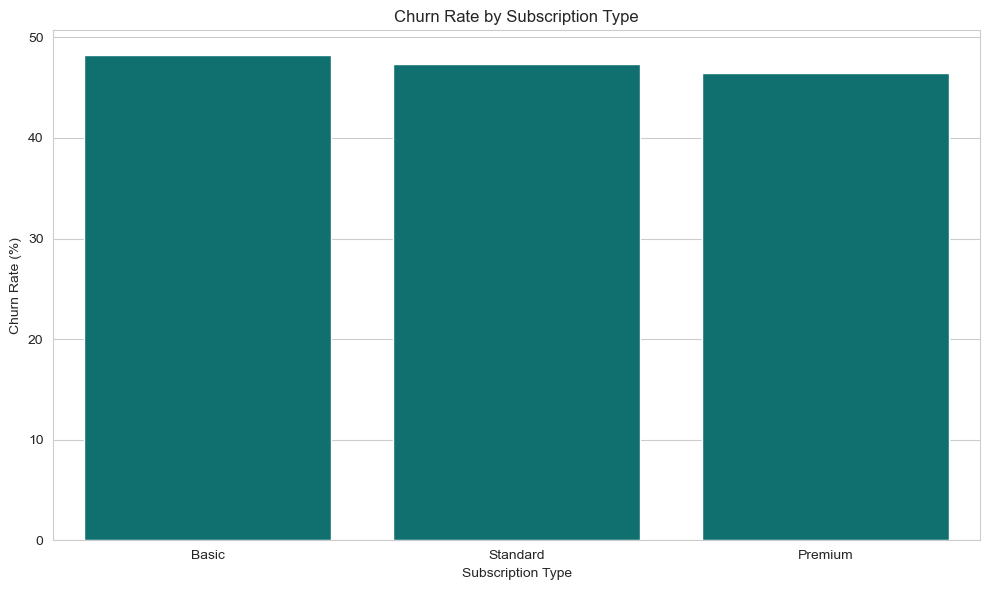

In [126]:
churn_by_sub = df.groupby("Subscription Type")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_sub.index,color="teal", y=churn_by_sub.values)
plt.title("Churn Rate by Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("chart_churn_by_subscription.png")
plt.show()

### Correlation heatmap
This shows which numeric columns move together with churn. Values near +1 or -1 mean a strong relationship; near 0 means weak.

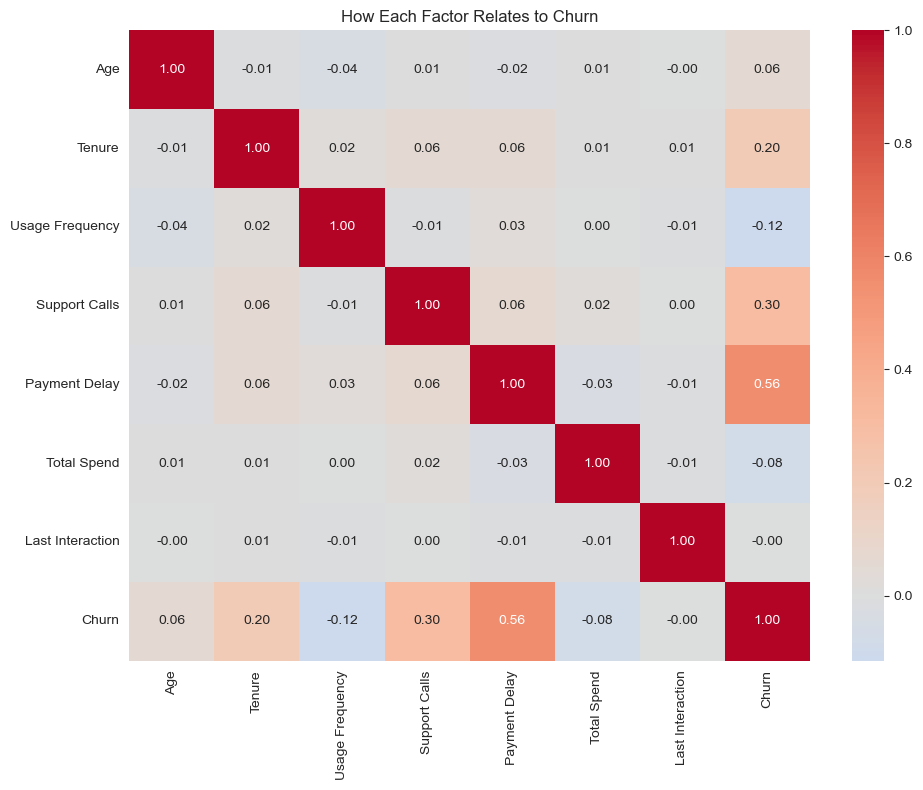

In [73]:
numeric_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls","Payment Delay", "Total Spend", "Last Interaction", "Churn"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("How Each Factor Relates to Churn")
plt.tight_layout()
plt.savefig("chart_correlation_heatmap.png")
plt.show()

The row/column for `Churn` — the darker the color (positive or negative) the stronger that feature's relationship with churn.

## 3. Prepared the data for machine learning
Models only understand numbers, so that I can convert text columns (like Gender, Contract Length) into numeric codes using `LabelEncoder`.

In [77]:
ml_data = df.drop(columns=["CustomerID"]).copy()  # ID isn't a useful predictor

text_columns = ["Gender", "Subscription Type", "Contract Length"]
for col in text_columns:
    encoder = LabelEncoder()
    ml_data[col] = encoder.fit_transform(ml_data[col])

X = ml_data.drop(columns=["Churn"])  
y = ml_data["Churn"]                 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training on {len(X_train)} customers, testing on {len(X_test)} customers")

Training on 51499 customers, testing on 12875 customers


## 4. Training the models

**Logistic Regression** — a simple, interpretable baseline model.

**Random Forest** — a more powerful model that combines many decision trees.

In [43]:
# Logistic Regression needs scaled data (mean 0, standard deviation 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_test_scaled)
log_probabilities = log_model.predict_proba(X_test_scaled)[:, 1]

In [45]:
# Random Forest doesn't need scaled data
rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

## 5. Evaluate the models

- **Precision**: everyone we predicted would churn, how many actually did?
- **Recall**: everyone who actually churned, how many did we catch?
- **F1**: balance between precision and recall

In [81]:
def print_scores(name, actual, predicted, probabilities):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(actual, predicted), 3))
    print("Precision:", round(precision_score(actual, predicted), 3))
    print("Recall   :", round(recall_score(actual, predicted), 3))
    print("F1 Score :", round(f1_score(actual, predicted), 3))
    print("ROC AUC  :", round(roc_auc_score(actual, probabilities), 3))
    print()

print_scores("Logistic Regression", y_test, log_predictions, log_probabilities)
print_scores("Random Forest", y_test, rf_predictions, rf_probabilities)

--- Logistic Regression ---
Accuracy : 0.826
Precision: 0.812
Recall   : 0.822
F1 Score : 0.817
ROC AUC  : 0.902

--- Random Forest ---
Accuracy : 0.999
Precision: 0.999
Recall   : 0.999
F1 Score : 0.999
ROC AUC  : 1.0



If Random Forest comes back near-perfect (99%+ accuracy) that's actually a flag worth mentioning in your write-up, not a pure win. It usually means the dataset has an unusually clean signal (common in synthetic/practice datasets like this one) rather than reflecting how messy real-world churn data usually is. Logistic Regression's more modest score is arguably more representative of real-world performance and pointing this out shows you're evaluating critically, not just chasing high numbers.

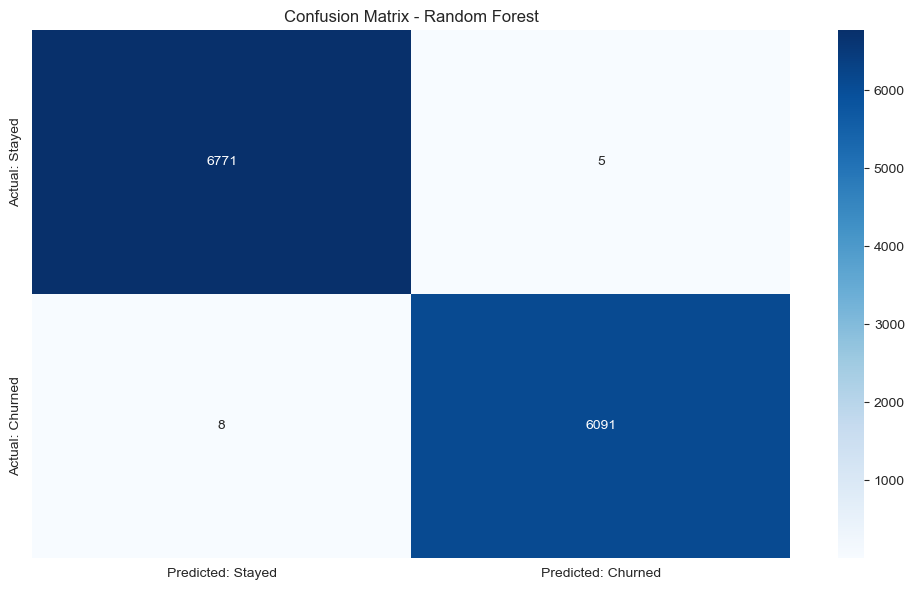

In [85]:
# confusion_matrix: a grid showing correct vs incorrect predictions
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Stayed", "Predicted: Churned"],
            yticklabels=["Actual: Stayed", "Actual: Churned"])
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.savefig("chart_confusion_matrix.png")
plt.show()

## 6. Which factors matter most?
This turns the model into a business insight — the real point of the whole project.

Payment Delay        0.446664
Support Calls        0.162510
Tenure               0.105633
Usage Frequency      0.088612
Gender               0.076766
Age                  0.038638
Total Spend          0.037959
Contract Length      0.035933
Last Interaction     0.004713
Subscription Type    0.002573
dtype: float64


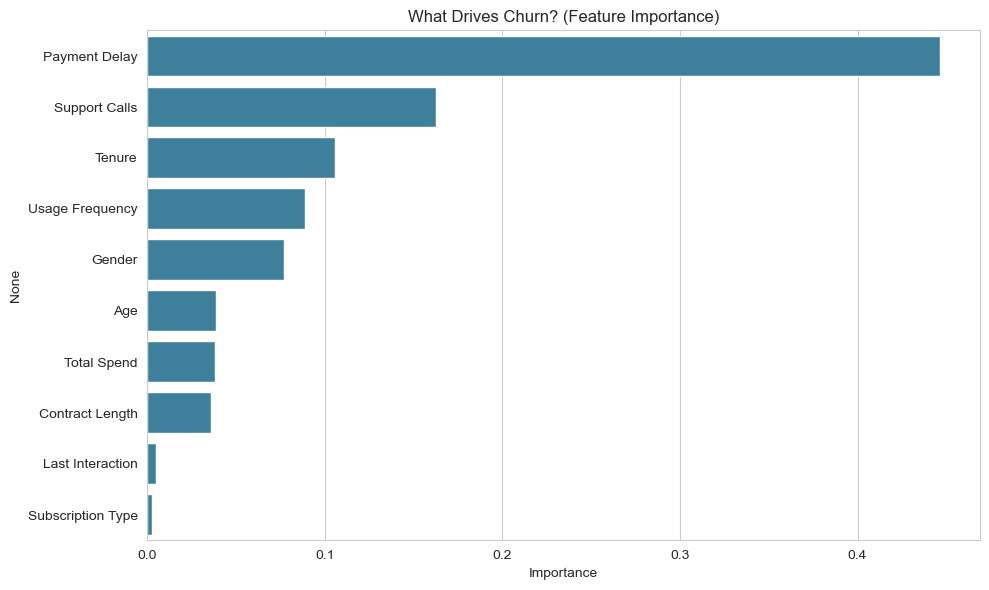

In [135]:
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index,color="#2E86AB")
plt.title("What Drives Churn? (Feature Importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("chart_feature_importance.png")
plt.show()

## 7. Score every customer's churn risk
This is what would actually get used by a business: a ranked list of customers most likely to churn, so retention efforts can be targeted. This file also feeds directly into the Power BI dashboard.

In [90]:
df["Churn_Probability"] = rf_model.predict_proba(X)[:, 1]
high_risk_customers = df.sort_values("Churn_Probability", ascending=False)
high_risk_customers.to_csv("customers_with_churn_risk.csv", index=False)

high_risk_customers[["CustomerID", "Contract Length", "Support Calls",
                      "Payment Delay", "Churn_Probability"]].head(10)

,CustomerID,Contract Length,Support Calls,Payment Delay,Churn_Probability
10304,10305,Monthly,8,26,1.0
58485,58486,Monthly,6,29,1.0
60314,60315,Monthly,8,30,1.0
52046,52047,Quarterly,7,23,1.0
64088,64089,Annual,10,30,1.0
31919,31920,Quarterly,7,28,1.0
219,220,Monthly,8,26,1.0
53419,53420,Annual,10,26,1.0
59336,59337,Monthly,6,26,1.0
60514,60515,Quarterly,5,27,1.0


## Summary

- **Payment Delay** and **Support Calls** were the strongest churn drivers in this dataset.
- **Monthly contracts** churn more than Quarterly or Annual ones, though the gap is moderate.
- **Subscription tier** barely affects churn — Basic, Standard, and Premium are all close.
- Logistic Regression (~83% accuracy, 0.90 AUC) is a realistic baseline; Random Forest's near-perfect score likely reflects the clean nature of this synthetic dataset rather than real-world conditions.
- The exported `customers_with_churn_risk.csv` ranks every customer by churn probability — ready to plug into the Power BI dashboard.